In [2]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.feature as cfeature


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut

In [3]:
# set up LDA 

# potential predictor variable X = oni 
# classification variable t = tercile ranking of the rainfall in subsequent season
# -> discriminant analysis calculates the conditional probability, P(t|X'), of occurrence of class t given a new observation X'
# for each of the three possible classes (above normal, near normal, below normal) 
# (Drosdowsky and Chambers, 2000)

In [4]:
mdb_mean = xr.open_dataset('data/mdb_mean_rainfall.nc')
mdb_total = xr.open_dataset('data/mdb_total_rainfall.nc')

mdb_mean_series = mdb_mean['precip'].to_series()
mdb_total_series = mdb_total['precip'].to_series()

In [5]:
# run with hadisst roni and oni
oni = xr.open_dataset('data/oni_hadisst.nc')
roni = xr.open_dataset('data/roni_hadisst.nc')

oni_series = oni['sst'].to_series()
roni_series = roni['sst'].to_series()


In [10]:
oni.month.values

array([1, 2, 3, ..., 5, 6, 7])

In [6]:
# extract predictor dataset (oni & roni)  
def get_oni_season(predictor_series, centre_month, year_offset=0):
    """Extract predictor values for seasons centered on a given month, relabeled by target year."""
    sub = oni_series[oni_series.index.month == centre_month].copy()
    sub.index = sub.index.year + year_offset # _.year 
    return sub

In [7]:
# # forecasting 1-month lead
# oni_ndj = get_oni_season (oni_series, centre_month = 12, year_offset = 1) # MAM following year 
# oni_fma = get_oni_season (oni_series, centre_month = 3, year_offset = 0) # JJA
# oni_mjj = get_oni_season (oni_series, centre_month = 6, year_offset = 0) # SON
# oni_aso = get_oni_season (oni_series, centre_month = 9, year_offset = 0) # DJF

# roni_ndj = get_oni_season (roni_series, centre_month = 12, year_offset = 1) # MAM following year 
# roni_fma = get_oni_season (roni_series, centre_month = 3, year_offset = 0) # JJA
# roni_mjj = get_oni_season (roni_series, centre_month = 6, year_offset = 0) # SON
# roni_aso = get_oni_season (roni_series, centre_month = 9, year_offset = 0) # DJF


In [8]:
# # forecasting with 3-month lead

# oni_son = get_oni_season(oni_series, centre_month=10, year_offset=1) # MAM
# oni_djf = get_oni_season(oni_series, centre_month= 1, year_offset=0) # JJA
# oni_mam = get_oni_season (oni_series, centre_month = 4, year_offset = 0) # SON
# oni_jja = get_oni_season (oni_series, centre_month = 7, year_offset = 1) # DJF

# roni_son = get_oni_season(roni_series, centre_month=10, year_offset=1) # MAM
# roni_djf = get_oni_season(roni_series, centre_month= 1, year_offset=0) # JJA
# roni_mam = get_oni_season (roni_series, centre_month = 4, year_offset = 0) # SON
# roni_jja = get_oni_season (roni_series, centre_month = 7, year_offset = 1) # DJF

In [9]:
# oni_ndj.loc[1998]
# roni_ndj.loc[1998]

In [10]:
# build non-overlapping rainfall seasons to start with, later maybe rolling season 

def seasonal_total(rain_series, season_months, year_offset=0):
    """season_months e.g. [3,4,5] for MAM. Handles DJF (crosses year boundary)
    automatically via year_offset if season_months=[12,1,2]."""
    sub = rain_series[rain_series.index.month.isin(season_months)].copy()
    
    if season_months == [12, 1, 2]:
        yr = sub.index.year.where(sub.index.month != 12, sub.index.year + 1) # if not 12, keet index year, if 12 add +1
    else:
        yr = sub.index.year
    
    total = sub.groupby(yr).sum() # total rainfall for 3 months
    counts = sub.groupby(yr).size() # number of months 
    total = total[counts == len(season_months)]  # keep only complete seasons, i.e. 3 months 
    total.index = total.index + year_offset
    return total


In [11]:
# rain_mam = seasonal_total(singlegrid_series, [3,4,5])
# rain_jja = seasonal_total(singlegrid_series, [6,7,8])
# rain_son = seasonal_total(singlegrid_series, [9,10,11])
# rain_djf = seasonal_total(singlegrid_series, [12,1,2])

In [12]:
# define Leave-One-Out-Cross_Validation function 
# For every observation, temporarily hide it, 
# use all the other observations to define the rainfall categories and train LDA, then predict the hidden observation.

def loocv_lda(X, rain_values): # X is predictor data 
    loo = LeaveOneOut() 
    n = len(rain_values) 
    preds = np.zeros(n, dtype=int) # stores LDA's predicted rainfall category for each year (below, near, above normal) 
    probs_all = np.zeros((n, 3)) # stores assigned probability LDA assigns to each category (adds up to 1) 
    obs_tercile = np.zeros(n, dtype=int) # stores actual observed rainfall category for each year 

    for train_idx, test_idx in loo.split(X): # generates training and testing indices from X predictor 
        q33, q67 = np.quantile(rain_values[train_idx], [1/3, 2/3]) # calculates 33rd and 67th percentiles using training data

        y_train = np.digitize(rain_values[train_idx], [q33, q67]) # converts rainfall data to catogories 0,1,2
        y_test  = np.digitize(rain_values[test_idx],  [q33, q67]) # does same for test data 

        lda_cv = LinearDiscriminantAnalysis() # creates LDA classifer: given predictor X, which rainfall tercile is most likely?
        lda_cv.fit(X[train_idx], y_train) # train only with training data 

        preds[test_idx]       = lda_cv.predict(X[test_idx]) # LDA predicts rainfall cateogry of test data 
        probs_all[test_idx]   = lda_cv.predict_proba(X[test_idx]) # LDA predicts probability for each rainfall category 
        obs_tercile[test_idx] = y_test # tells observed/acutal category of test data


    return preds, probs_all, obs_tercile


In [13]:
# Basic skill metrics (Heidke_skill_score -> hit/miss)

def hit_rate(preds, obs):
    return np.mean(preds == obs)

def heidke_skill_score(preds, obs, n_classes=3):
    n = len(obs)
    correct = np.sum(preds == obs)
    expected_correct = n / n_classes
    return (correct - expected_correct) / (n - expected_correct)

In [14]:
# Season / lead-time definitions

season_config = {
    'DJF': {'months': [12,1,2], 'center_1mo': 9,  'offset_1mo': 0, 'center_3mo': 7,  'offset_3mo': 1 }, # double check 
    'MAM': {'months': [3,4,5],  'center_1mo': 12, 'offset_1mo': 1, 'center_3mo': 10, 'offset_3mo': 1},
    'JJA': {'months': [6,7,8],  'center_1mo': 3,  'offset_1mo': 0, 'center_3mo': 1,  'offset_3mo': 0},
    'SON': {'months': [9,10,11],'center_1mo': 6,  'offset_1mo': 0, 'center_3mo': 4,  'offset_3mo': 0},
}

In [15]:
# build dataset and run LOOCV LDA with ONI 1month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(oni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(mdb_mean_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_1mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=125, hit_rate=0.400, HSS=0.100
MAM: n=126, hit_rate=0.405, HSS=0.107
JJA: n=126, hit_rate=0.429, HSS=0.143
SON: n=126, hit_rate=0.429, HSS=0.143


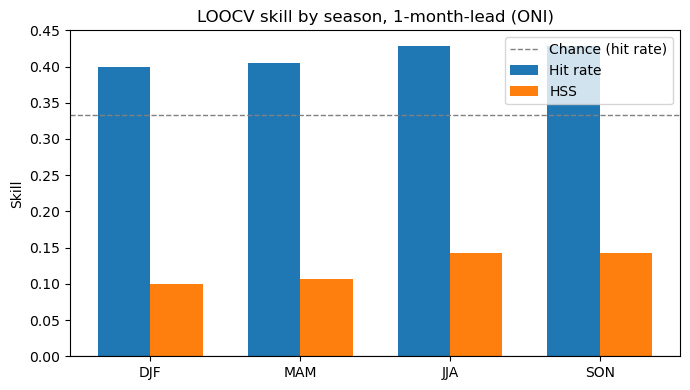

In [16]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 1-month-lead (ONI)')
ax.legend()
plt.tight_layout()
plt.show()

DJF: n=125, hit_rate=0.376, HSS=0.064
MAM: n=126, hit_rate=0.397, HSS=0.095
JJA: n=126, hit_rate=0.405, HSS=0.107
SON: n=126, hit_rate=0.333, HSS=0.000


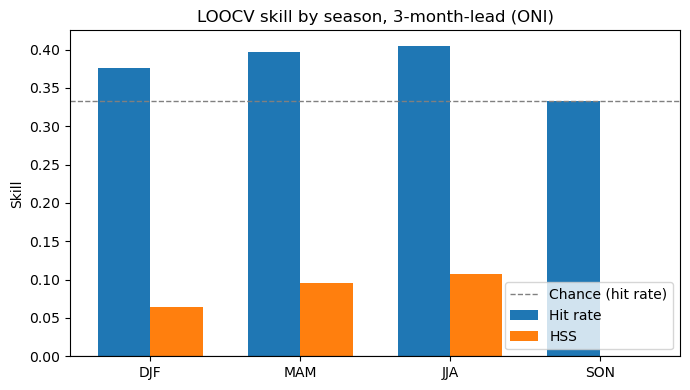

In [17]:
# build dataset and run LOOCV LDA with ONI 3month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(oni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(mdb_mean_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_3mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")


seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 3-month-lead (ONI)')
ax.legend()
plt.tight_layout()
plt.show()
    

In [18]:
def plot_lda_1d(season_name, X_1d, y, ax=None, predictor_label='ONI'):
    """X_1d: shape (n,) or (n,1) - single predictor values
       y: tercile labels (0,1,2)"""
    X_1d = np.asarray(X_1d).reshape(-1, 1)
    
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_1d, y)   # full-data fit, for visualization only - not a skill claim
    
    x_min, x_max = X_1d.min() - 0.5, X_1d.max() + 0.5
    x_grid = np.linspace(x_min, x_max, 500).reshape(-1, 1)
    
    class_pred = lda.predict(x_grid)
    probs = lda.predict_proba(x_grid)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,4))
    
    # background strip showing predicted class region
    colors = ['#4575b4', '#ffffbf', '#d73027']  # below/near/above
    for i in range(len(x_grid)-1):
        ax.axvspan(x_grid[i,0], x_grid[i+1,0], color=colors[class_pred[i]], alpha=0.15, lw=0)
    
    # posterior probability curves
    labels = ['P(Below)', 'P(Near)', 'P(Above)']
    for c in range(3):
        ax.plot(x_grid, probs[:,c], color=colors[c], label=labels[c], linewidth=2)
    
    # actual observed data points, jittered slightly on y for visibility
    for c in range(3):
        mask = y == c
        ax.scatter(X_1d[mask], np.full(mask.sum(), -0.05), color=colors[c], 
                   edgecolor='k', s=40, zorder=5)
    
    # mark decision boundaries (where predicted class changes)
    boundaries = x_grid[:-1][np.diff(class_pred) != 0]
    for b in boundaries:
        ax.axvline(b[0], color='gray', linestyle='--', linewidth=1)
    
    ax.set_xlabel(predictor_label)
    ax.set_ylabel('Posterior probability')
    ax.set_ylim(-0.12, 1.05)
    ax.set_title(f'{season_name}: LDA decision regions ({predictor_label})')
    ax.legend(fontsize=8, loc='upper left')
    return ax



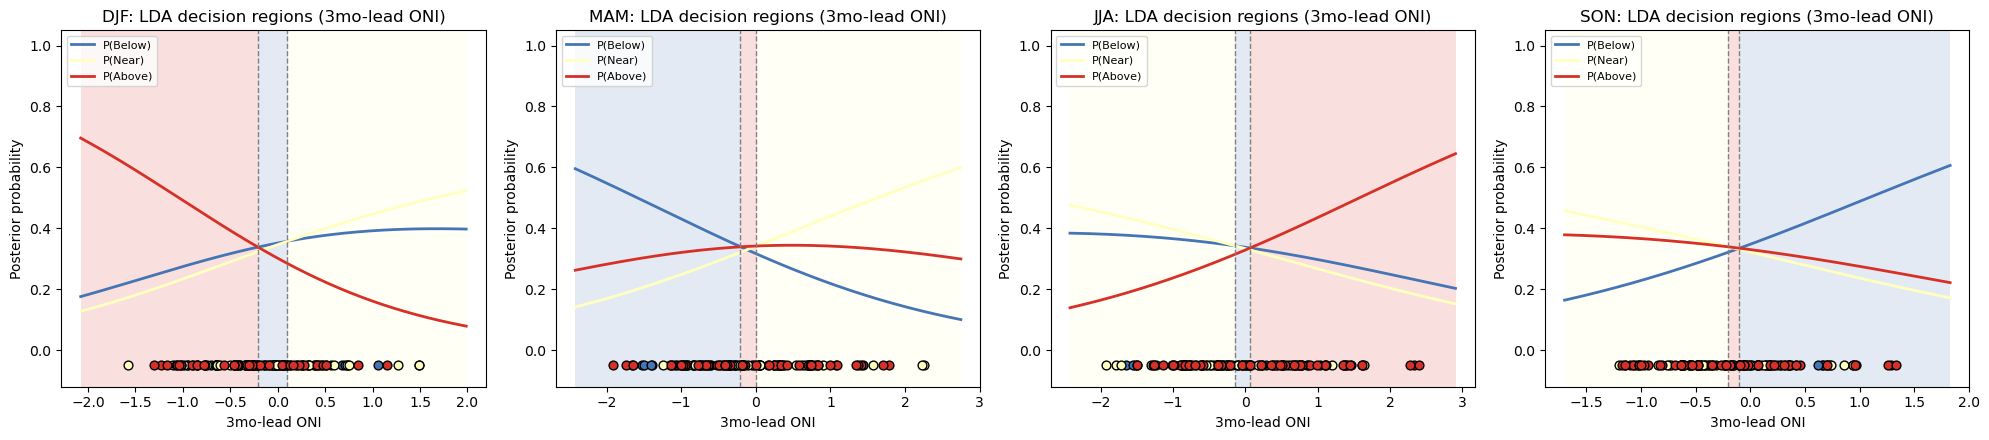

In [19]:
# 3 months oni
fig, axes = plt.subplots(1, 4, figsize=(20,4.5))

for ax, season_name in zip(axes, season_config.keys()):
    cfg = season_config[season_name]
    oni_3mo = get_oni_season(oni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(mdb_mean_series, cfg['months'])
    oni_3mo.name = 'oni_3mo'
    rain.name = 'rain'
    
    df = pd.concat([oni_3mo, rain], axis=1).dropna()
    q33, q67 = df['rain'].quantile([1/3, 2/3])
    df['tercile'] = pd.cut(df['rain'], bins=[-np.inf,q33,q67,np.inf], labels=[0,1,2]).astype(int)
    
    plot_lda_1d(season_name, df['oni_3mo'].values, df['tercile'].values, ax=ax, 
                predictor_label='3mo-lead ONI')

plt.tight_layout()
plt.show()

In [20]:
# build dataset and run LOOCV LDA with RONI 1month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(roni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(mdb_mean_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_1mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=125, hit_rate=0.400, HSS=0.100
MAM: n=126, hit_rate=0.405, HSS=0.107
JJA: n=126, hit_rate=0.429, HSS=0.143
SON: n=126, hit_rate=0.429, HSS=0.143


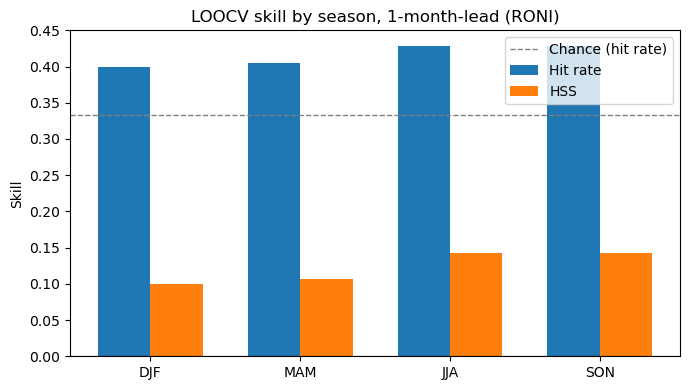

In [21]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 1-month-lead (RONI)')
ax.legend()
plt.tight_layout()
plt.show()
    

In [22]:
# build dataset and run LOOCV LDA with RONI 3month

results = {}

for season_name, cfg in season_config.items():
    oni_1mo = get_oni_season(roni_series, cfg['center_1mo'], cfg['offset_1mo'])
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(mdb_mean_series, cfg['months'])

    oni_1mo.name = 'oni_1mo_lead'
    oni_3mo.name = 'oni_3mo_lead'
    rain.name    = 'rain'

    # terciles computed on the FULL rainfall record, before any ONI merge
    q33, q67 = rain.quantile([1/3, 2/3])
    
    # merge to predictor length 
    df = pd.concat([oni_1mo, oni_3mo, rain], axis=1).dropna()

    X = df[['oni_3mo_lead']].values
    rain_vals = df['rain'].values

    preds, probs_all, obs = loocv_lda(X, rain_vals)

    results[season_name] = {
        'n_years': len(df),
        'preds': preds,
        'probs': probs_all,
        'obs': obs,
        'hit_rate': hit_rate(preds, obs),
        'hss': heidke_skill_score(preds, obs),
    }

    print(f"{season_name}: n={results[season_name]['n_years']}, "
          f"hit_rate={results[season_name]['hit_rate']:.3f}, "
          f"HSS={results[season_name]['hss']:.3f}")

DJF: n=125, hit_rate=0.376, HSS=0.064
MAM: n=126, hit_rate=0.397, HSS=0.095
JJA: n=126, hit_rate=0.405, HSS=0.107
SON: n=126, hit_rate=0.333, HSS=0.000


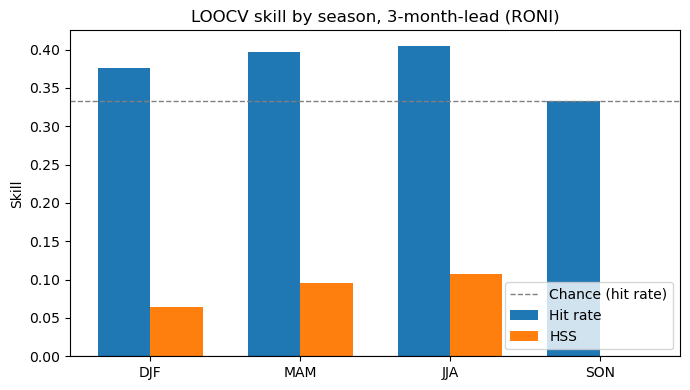

In [23]:
seasons = list(results.keys())
hit_rates = [results[s]['hit_rate'] for s in seasons]
hss_vals  = [results[s]['hss'] for s in seasons]

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(seasons))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label='Hit rate')
ax.bar(x + width/2, hss_vals, width, label='HSS')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Chance (hit rate)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Skill')
ax.set_title('LOOCV skill by season, 3-month-lead (RONI)')
ax.legend()
plt.tight_layout()
plt.show()

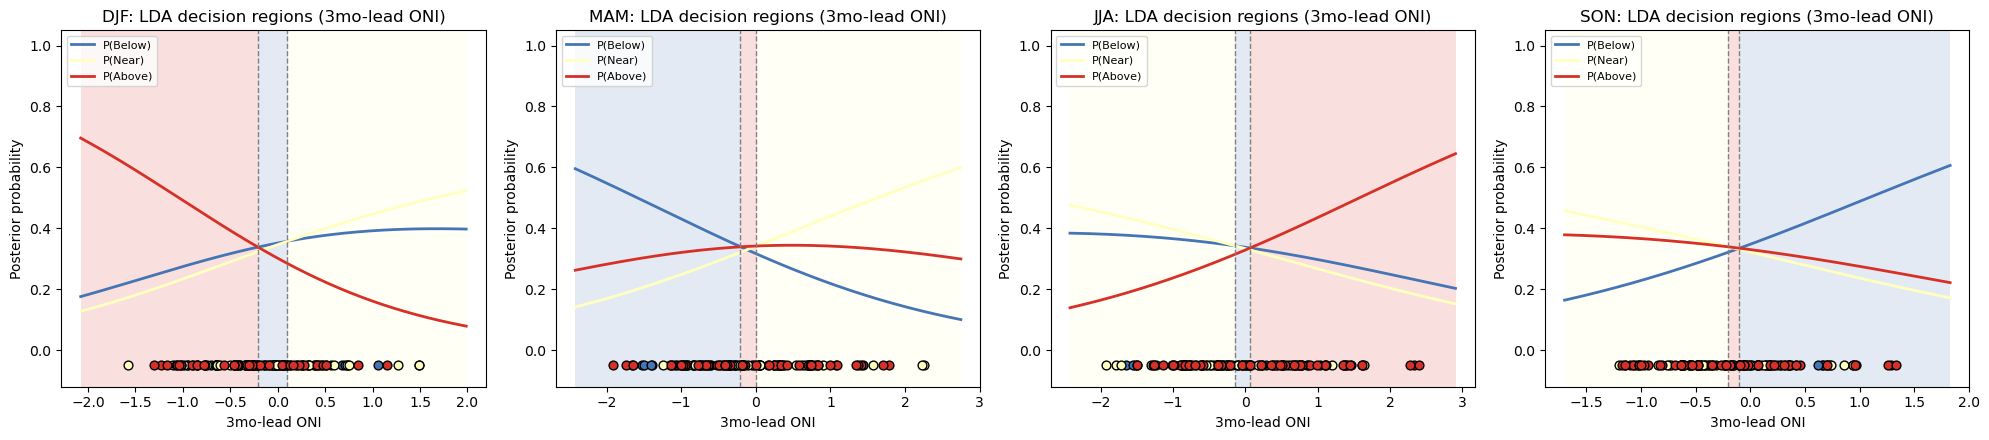

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(20,4.5))

for ax, season_name in zip(axes, season_config.keys()):
    cfg = season_config[season_name]
    oni_3mo = get_oni_season(roni_series, cfg['center_3mo'], cfg['offset_3mo'])
    rain    = seasonal_total(mdb_mean_series, cfg['months'])
    oni_3mo.name = 'oni_3mo'
    rain.name = 'rain'
    
    df = pd.concat([oni_3mo, rain], axis=1).dropna()
    q33, q67 = df['rain'].quantile([1/3, 2/3])
    df['tercile'] = pd.cut(df['rain'], bins=[-np.inf,q33,q67,np.inf], labels=[0,1,2]).astype(int)
    
    plot_lda_1d(season_name, df['oni_3mo'].values, df['tercile'].values, ax=ax, 
                predictor_label='3mo-lead ONI')

plt.tight_layout()
plt.show()

In [25]:
# check why exact same oni vs roni -> probs tercile classification, predictions fall in the same categories 
# improving or worsening by time? need to check by splitting up, where roni/oni diverges - 2013?


In [26]:
# compare hindcast access - how? leps? bureau weighted something 

In [27]:
print(season_name)


SON


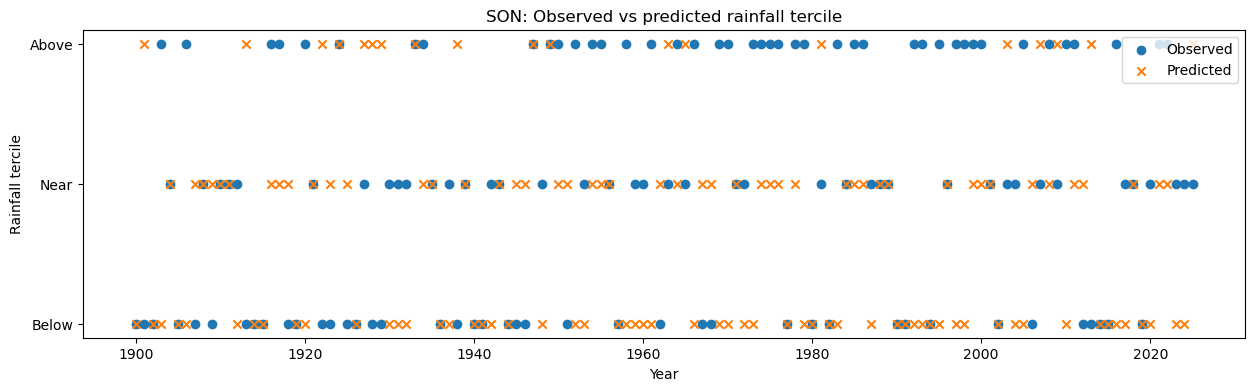

In [28]:
tercile_names = {
    0: 'Below',
    1: 'Near',
    2: 'Above'
}

obs = results[season_name]['obs']
preds = results[season_name]['preds']

plt.figure(figsize=(15, 4))

plt.scatter(df.index, obs, label='Observed')
plt.scatter(df.index, preds, label='Predicted', marker = 'x')

plt.yticks([0, 1, 2], ['Below', 'Near', 'Above'])
plt.xlabel('Year')
plt.ylabel('Rainfall tercile')
plt.title(f'{season_name}: Observed vs predicted rainfall tercile')
plt.legend()
plt.show()

In [37]:
roni['sst']

<xarray.DataArray 'sst' (time: 1879)> Size: 8kB
array([      nan, -0.612827, -0.505451, ...,  0.485978,  0.976325,       nan],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
    month    (time) int64 15kB ...

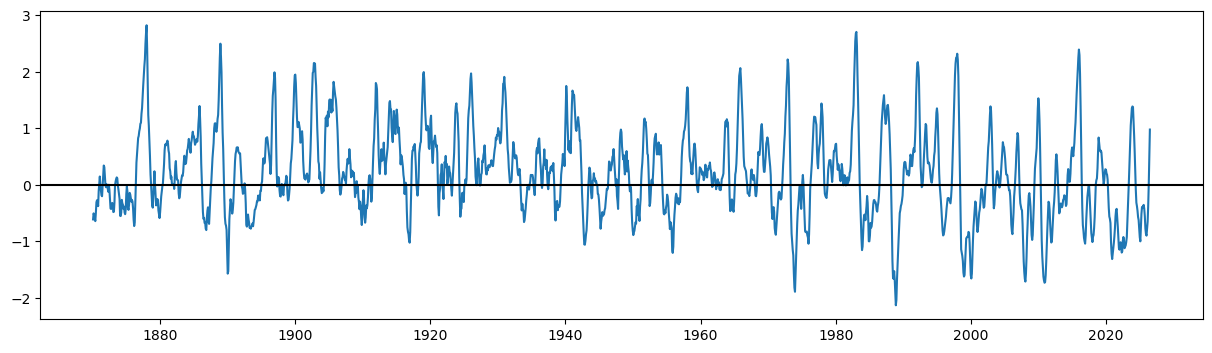

In [47]:
plt.figure(figsize = (15,4))
plt.plot(roni['time'],roni['sst'])
plt.axhline(y=0, color = 'black')

In [57]:
print(roni.time.dt.year.where(roni.sst >= 1, drop=True).values)

[1877. 1877. 1877. 1877. 1877. 1877. 1877. 1877. 1877. 1877. 1877. 1878.
 1878. 1878. 1878. 1878. 1885. 1885. 1885. 1885. 1888. 1888. 1888. 1888.
 1888. 1888. 1888. 1888. 1888. 1889. 1889. 1889. 1896. 1896. 1896. 1896.
 1896. 1897. 1897. 1899. 1899. 1899. 1899. 1900. 1900. 1900. 1900. 1900.
 1900. 1900. 1900. 1902. 1902. 1902. 1902. 1902. 1902. 1902. 1903. 1903.
 1903. 1903. 1904. 1904. 1904. 1904. 1904. 1904. 1905. 1905. 1905. 1905.
 1905. 1905. 1905. 1905. 1905. 1905. 1905. 1905. 1906. 1906. 1906. 1911.
 1911. 1911. 1912. 1912. 1912. 1913. 1913. 1914. 1914. 1914. 1914. 1914.
 1914. 1914. 1914. 1915. 1915. 1915. 1915. 1918. 1918. 1918. 1918. 1919.
 1919. 1919. 1919. 1919. 1919. 1919. 1920. 1920. 1923. 1923. 1923. 1923.
 1924. 1924. 1925. 1925. 1925. 1925. 1925. 1926. 1926. 1926. 1926. 1926.
 1930. 1930. 1930. 1930. 1930. 1930. 1931. 1931. 1931. 1931. 1940. 1940.
 1940. 1940. 1940. 1940. 1941. 1941. 1941. 1941. 1941. 1941. 1941. 1941.
 1941. 1941. 1942. 1951. 1951. 1951. 1951. 1957. 19

In [59]:
df

,oni_3mo,rain,tercile
time,,,
1900,0.659105,56.447460,0
1901,-0.167948,79.631111,0
1902,0.058408,75.419838,0
1903,0.277011,177.986877,2
1904,-0.729461,97.845367,1
...,...,...,...
2021,-0.633420,202.815903,2
2022,-0.997400,297.062531,2
2023,0.124761,106.507629,1


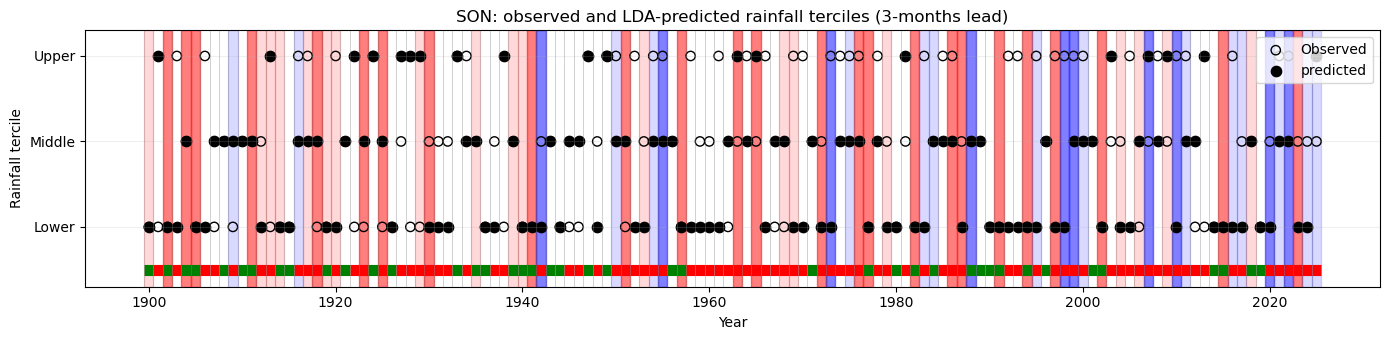

In [79]:
years = df.index

# Observed rainfall terciles
q33, q67 = df['rain'].quantile([1/3, 2/3])

obs_tercile = np.where(
    df['rain'] <= q33, 1,
    np.where(df['rain'] <= q67, 2, 3)
)

# LDA predicted terciles
pred_tercile = np.array(preds) + 1   # remove +1 if preds are already 1, 2, 3

# ENSO values: 
enso_son = roni['sst'].where(
    ((roni.time.dt.year >= 1900) & (roni.time.dt.month == 10))
    , drop = True)

fig, ax = plt.subplots(figsize=(14, 3.5))

# Background ENSO phase
for i, year in enumerate(years):
    if enso_son[i] >= 1:
        ax.axvspan(
            year - 0.5, year + 0.5,
            alpha=0.5, color='red'
        )
    elif enso_son[i] >= 0.5:
        ax.axvspan(
            year - 0.5, year + 0.5,
            alpha=0.15, color='red'
        )
    elif enso_son[i] <= -1:
        ax.axvspan(
            year - 0.5, year + 0.5,
            alpha=0.5, color='blue'
        )
    elif enso_son[i] <= -0.5:
        ax.axvspan(
            year - 0.5, year + 0.5,
            alpha=0.15, color='blue'
        )

# Observed and predicted terciles
ax.scatter(
    years,
    obs_tercile,
    marker='o',
    facecolors = 'none',
    edgecolors='k',
    s=45,
    label='Observed'
)

ax.scatter(
    years,
    pred_tercile,
    marker='o',
    color = 'k',
    s=55,
    label='predicted'
)

match = obs_tercile == pred_tercile

for i, year in enumerate(years):
    ax.hlines(
        y=0.5,
        xmin=year - 0.5,
        xmax=year + 0.5,
        color='green' if match[i] else 'red',
        linewidth=8
    )

for year in years:
    ax.axvline(year - 0.5, color='grey', linewidth=0.5, alpha=0.5)

# Tercile labels
ax.set_ylim(0.3, 3.3)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Lower', 'Middle', 'Upper'])

ax.set_xlabel('Year')
ax.set_ylabel('Rainfall tercile')
ax.set_title(f'{season_name}: observed and LDA-predicted rainfall terciles (3-months lead)')

ax.legend(loc = 1)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# 뭐 맞춘게 없어;; 

In [ ]:
# assess model skill for out-of-sample predictors (training model on R(ONI) from 1950-2000, then assess predictive skill from 2001-2020


In [ ]:
# k-fold 
# sliding windows 
# lead-time investigations